In [36]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import numpy as np
import pickle

In [122]:
link = pd.read_csv(r'bm_003_7 subcellular regulation.txt', sep='\t')

In [123]:
link

,regulator,target,link
0,ACAN,MALAT1,0.251019
1,COL1A1,IL6,0.240062
2,ACTB,GAPDH,0.227136
3,GAPDH,ACTB,0.218270
4,IL6,COL1A1,0.216857
...,...,...,...
751,CD19,IL6,0.003189
752,CCL11,COL1A1,0.003188
753,NANOG,IL6,0.003082
754,NANOG,COL5A2,0.003064


In [124]:
edge_length = np.array(link['link'].tolist())*2

In [125]:
graph_ne = list(zip(link['regulator'].tolist(), link['target'].tolist(), edge_length))

In [126]:
graph_ne[:30]

[('ACAN', 'MALAT1', 0.502038),
 ('COL1A1', 'IL6', 0.480124),
 ('ACTB', 'GAPDH', 0.454272),
 ('GAPDH', 'ACTB', 0.43654),
 ('IL6', 'COL1A1', 0.433714),
 ('COL1A1', 'COL5A2', 0.432084),
 ('COL5A2', 'COL1A1', 0.429442),
 ('MALAT1', 'ACAN', 0.411148),
 ('COL5A2', 'IL6', 0.386954),
 ('IL6', 'COL5A2', 0.350708),
 ('GAPDH', 'IBSP', 0.346588),
 ('MALAT1', 'RUNX1', 0.32791),
 ('CD34', 'MALAT1', 0.291004),
 ('COL1A1', 'MKI67', 0.288752),
 ('CD105', 'CD45', 0.27955),
 ('ACAN', 'CD34', 0.274522),
 ('MKI67', 'EEF2', 0.272712),
 ('MKI67', 'IL6', 0.272074),
 ('IL6', 'MKI67', 0.271794),
 ('ACAN', 'RUNX1', 0.262882),
 ('IBSP', 'GAPDH', 0.256874),
 ('CD34', 'ACAN', 0.24931),
 ('MKI67', 'COL1A1', 0.241556),
 ('MALAT1', 'CD34', 0.23907),
 ('RUNX1', 'PTH1R', 0.231996),
 ('EEF2', 'MKI67', 0.226044),
 ('COL1A1', 'ACTB', 0.225518),
 ('CXCR4', 'CD90', 0.21936),
 ('IBSP', 'ACTB', 0.218236),
 ('EEF2', 'IBSP', 0.215964)]

In [127]:
dg = nx.DiGraph()
dg.add_weighted_edges_from(graph_ne[:30])

In [131]:
pos = nx.planar_layout(dg)

In [132]:
for k in pos.keys():
    pos[k] = pos[k] * 2

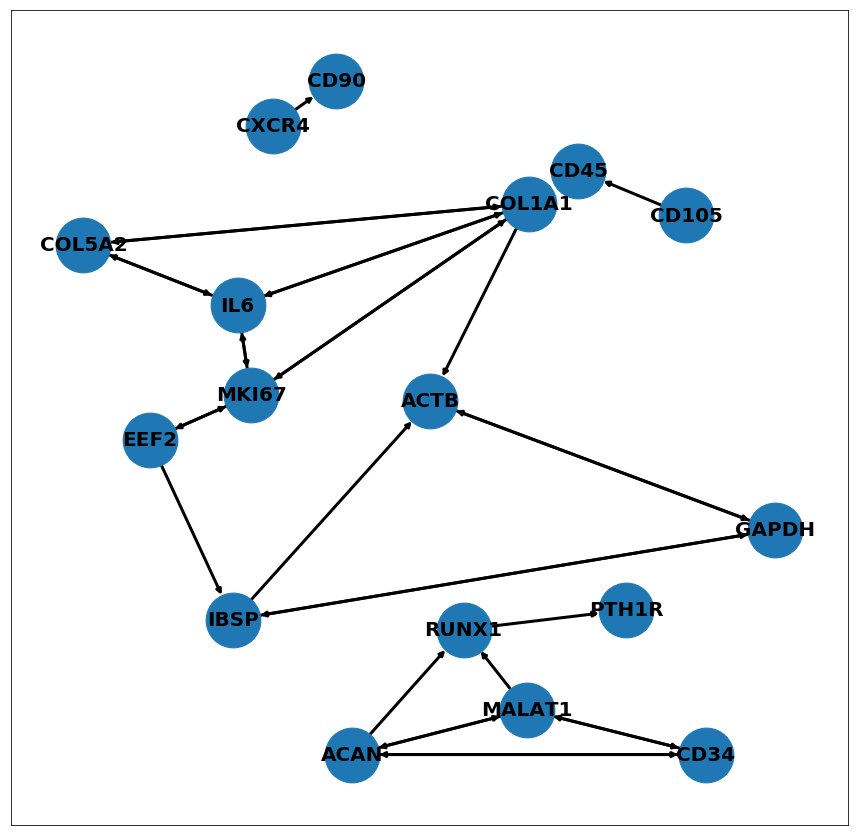

In [194]:
with rc_context({'figure.figsize': (15, 15)}):
    # nx.draw_networkx_nodes(dg, pos, node_size = 1)
    # nx.draw_networkx_labels(dg, pos, font_size=18, font_weight='bold')
    # nx.draw_networkx_edges(dg, pos, arrows=True, arrowsize=20)
    nx.draw_networkx(dg, pos = pos, arrows=True, arrowsize=10, width=3, node_size=3000, font_weight='bold', font_size=20)
plt.savefig('bm_003_7 28 markers link planar.png')

In [192]:
pos['IL6'][0] = pos['IL6'][0]-1.0
# pos['COL1A1'][1] = pos['COL1A1'][1]+0.3
# pos['ACTB'][1] = pos['ACTB'][1]+0.5

In [195]:
pickle.dump(pos, open('bm_003_7 28 markers positions.pkl', 'wb'))